In [8]:
!pip install folium

In [9]:
import folium
import numpy as np
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, Point, box
from IPython.display import display, HTML

Para este ejercicio se uso la libreria de voronoi, y la proyección sobre el mapa se realizo con folium y HTML

In [10]:
def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite voronoi regions in a 2D diagram to finite
    regions.
    Source: https://stackoverflow.com/questions/20515554/colorize-voronoi-diagram
    """
    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = vor.points.ptp().max()*2

    # Construct a map containing all ridges for a given point
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Reconstruct infinite regions
    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]

        if all(v >= 0 for v in vertices):
            # finite region
            new_regions.append(vertices)
            continue

        # reconstruct a non-finite region
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:
                # finite ridge: already in the region
                continue

            # Compute the missing endpoint of an infinite ridge

            t = vor.points[p2] - vor.points[p1] # tangent
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])  # normal

            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius

            new_region.append(len(new_vertices))
            new_vertices.append(far_point.tolist())

        # sort region counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = np.array(new_region)[np.argsort(angles)]

        # finish
        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)


Para esto se presentan los colegios en la zona de puente aranda en donde se observa una acumulación de cursos en torno a las avenidas

In [ ]:
# --- CONFIGURACIÓN DE PUNTOS ---
PUNTOS = {
    "Jose Manuel Restrepo": (4.617701, -74.122509),
    "Galileo": (4.614575, -74.118691),
    "Santisimo sacramento": (4.615114, -74.117287),
    "ITEC": (4.615807, -74.116573),
    "Gimnasio moderno": (4.617533, -74.115996),
    "Romel Velasco": (4.617518, -74.114353),
    "Liceo Diana Paola": (4.617297, -74.113524),
    "Psicopedagogico": (4.618060, -74.113273),
    "Sorrento B": (4.619925, -74.113520),
    "Señora del Rosario": (4.621044, -74.119724),
    "Luis Carlos Sarmiento": (4.611641, -74.119104),
    "Nuestra señora teresita": (4.622207, -74.118410),
    "Nuestra señora de La Salette": (4.624177, -74.116248),
    "Sorrento A": (4.623080, -74.113438)
}

# LÍMITES RECTANGULARES (Bounding Box)
# Aproximadamente Colombia
LAT_MIN, LAT_MAX = 4.611506, 4.626863
LON_MIN, LON_MAX = -74.124001, -74.107063


In [12]:
# Extraer nombres y coordenadas
nombres = list(PUNTOS.keys())
coords = np.array(list(PUNTOS.values()))

# Invertir para Voronoi (Lon, Lat) porque Voronoi usa (x, y) y mapa es (x=Lon, y=Lat)
points = np.array([[lon, lat] for lat, lon in coords])

# Crear el objeto Voronoi
vor = Voronoi(points)

# Crear el mapa base centrado en Colombia
m = folium.Map(location=[4.5709, -74.2973], zoom_start=6, tiles='CartoDB positron')

# Crear el rectángulo delimitador (Bounding Box)
# box(minx, miny, maxx, maxy) -> (LonMin, LatMin, LonMax, LatMax)
bounding_box = box(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)


# Dibujar el bounding box en el mapa (opcional, para referencia)
folium.Rectangle(
    bounds=[[LAT_MIN, LON_MIN], [LAT_MAX, LON_MAX]],
    color="black",
    weight=1,
    fill=False,
    dash_array="5, 5"
).add_to(m)

# Convertir regiones infinitas a finitas (pintar todas las celdas)
regions, vertices = voronoi_finite_polygons_2d(vor)

# Dibujar las regiones de Voronoi recortadas
# vor.point_region mapea índice de punto -> índice de región
# Pero voronoi_finite_polygons_2d devuelve regiones en orden de puntos (p0, p1...)

for i, region in enumerate(regions):
    # Crear polígono Shapely con los vértices reconstruidos
    polygon_coords = vertices[region]
    poly_voronoi = Polygon(polygon_coords)
        
    # Intersección: Voronoi recortado por el Rectángulo
    # Esto asegura que las celdas infinitas se corten limpiamente en el borde
    final_poly = poly_voronoi.intersection(bounding_box)
    
    if not final_poly.is_empty:
        # Extraer coordenadas para Folium (Lat, Lon)
        if final_poly.geom_type == 'Polygon':
            x, y = final_poly.exterior.coords.xy
            folium_coords = list(zip(y, x))
            
            # Añadir al mapa
            folium.Polygon(
                locations=folium_coords,
                color='blue',
                weight=1,
                fill=True,
                fill_color='#3186cc',
                fill_opacity=0.3, # Más opacidad para ver relleno
                popup=f"Área {nombres[i]}"
            ).add_to(m)
        elif final_poly.geom_type == 'MultiPolygon':
            for poly in final_poly.geoms:
                x, y = poly.exterior.coords.xy
                folium_coords = list(zip(y, x))
                folium.Polygon(
                    locations=folium_coords,
                    color='blue',
                    weight=1,
                    fill=True,
                    fill_color='#3186cc',
                    fill_opacity=0.3,
                    popup=f"Área {nombres[i]}"
                ).add_to(m)

# Añadir marcadores para las ciudades
for nombre, (lat, lon) in PUNTOS.items():
    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        popup=nombre,
        color='red',
        fill=True,
        fill_color='red'
    ).add_to(m)

# Guardar y avisa
m.save("voronoi.html")
print("Mapa generado exitosamente como 'voronoi.html'. Ábrelo en tu navegador.")
m


Mapa generado exitosamente como 'voronoi.html'. Ábrelo en tu navegador.


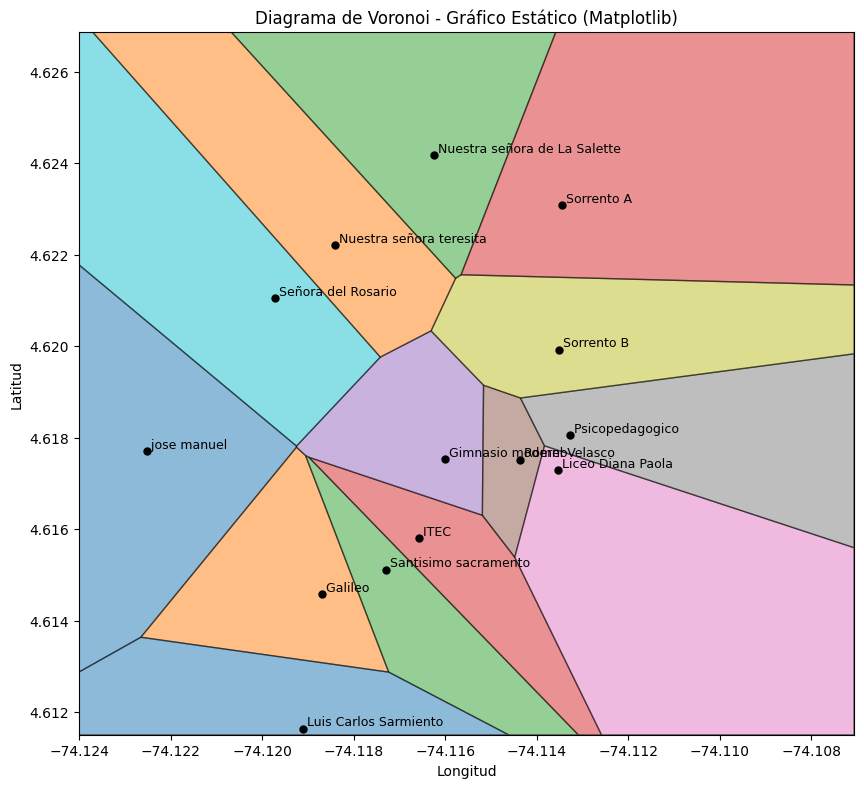

In [ ]:
!pip install matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 10))

# Usaremos los colores nativos definidos por matplotlib
colores = list(mcolors.TABLEAU_COLORS.values())

# Dibujar las regiones de Voronoi recortadas
for i, region in enumerate(regions):
    polygon_coords = vertices[region]
    poly_voronoi = Polygon(polygon_coords)
    final_poly = poly_voronoi.intersection(bounding_box)
    
    if not final_poly.is_empty:
        # Extraer coordenadas x,y (lon, lat para matplotlib)
        if final_poly.geom_type == 'Polygon':
            x, y = final_poly.exterior.coords.xy
            p = MplPolygon(list(zip(x, y)), facecolor=colores[i % len(colores)], edgecolor='black', alpha=0.5)
            ax.add_patch(p)
        elif final_poly.geom_type == 'MultiPolygon':
            for poly in final_poly.geoms:
                x, y = poly.exterior.coords.xy
                p = MplPolygon(list(zip(x, y)), facecolor=colores[i % len(colores)], edgecolor='black', alpha=0.5)
                ax.add_patch(p)

# Añadir los marcadores y nombres de ciudades
for nombre, (lat, lon) in PUNTOS.items():
    ax.plot(lon, lat, 'ko', markersize=5)
    ax.text(lon, lat, f' {nombre}', fontsize=9, verticalalignment='bottom')

# Ajustar vista general
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect('equal') # Mantener la proporción geométrica de mapa

plt.title('Diagrama de Voronoi - Gráfico Estático')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()
